In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_log_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

In [2]:
train = pd.read_csv('../data/processed/train_featured.csv')

train.head()

,store_nbr,family,sales,onpromotion,dcoilwtico,city,state,type,cluster,transactions,...,day_of_week,week_of_year,is_weekend,quarter,sales_lag_7,sales_lag_14,sales_lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28
0,1,0,2.0,0,97.620000,18,12,3,13,1772.0,...,1,5,0,1,1.0,1.0,0.0,2.571429,2.142857,2.142857
1,1,0,6.0,0,97.980000,18,12,3,13,1877.0,...,2,5,0,1,3.0,1.0,2.0,2.714286,2.214286,2.214286
2,1,0,0.0,0,97.650000,18,12,3,13,1707.0,...,3,5,0,1,0.0,1.0,3.0,3.142857,2.571429,2.357143
3,1,0,3.0,0,97.460000,18,12,3,13,1806.0,...,4,5,0,1,5.0,0.0,3.0,3.142857,2.500000,2.250000
4,1,0,0.0,0,97.459649,18,12,3,13,1377.0,...,5,5,1,1,4.0,5.0,5.0,2.857143,2.714286,2.250000


In [3]:
# Train/Validation Split (Time-Based)
train = train.sort_values(['store_nbr', 'family'])

X = train.drop(columns=['sales'])
y = train['sales']

split_index = int(len(train) * 0.8)

X_train, X_val = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_val = y.iloc[:split_index], y.iloc[split_index:]

print(X_train.shape, X_val.shape)

(2360793, 23) (590199, 23)


In [4]:
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    preds = np.clip(preds, 0, None)
    
    rmsle = np.sqrt(mean_squared_log_error(y_val, preds))
    results[name] = rmsle
    print(f'{name}: RMSLE = {rmsle:.4f}')

Random Forest: RMSLE = 0.5798
XGBoost: RMSLE = 1.1936
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056829 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2484
[LightGBM] [Info] Number of data points in the train set: 2360793, number of used features: 23
[LightGBM] [Info] Start training from score 299.873727
LightGBM: RMSLE = 1.0503


In [7]:
# Use a sample to avoid memory issues
sample_size = 300000
sample_idx = np.random.choice(len(X_train), sample_size, replace=False)
X_train_sample = X_train.iloc[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

rf_tuned = RandomForestRegressor(
    n_estimators=200, 
    max_depth=15, 
    min_samples_split=5,
    random_state=42, 
    n_jobs=-1
)

rf_tuned.fit(X_train_sample, y_train_sample)
preds_tuned = rf_tuned.predict(X_val)
preds_tuned = np.clip(preds_tuned, 0, None)

rmsle_tuned = np.sqrt(mean_squared_log_error(y_val, preds_tuned))
print(f'Tuned RF (sample-trained): RMSLE = {rmsle_tuned:.4f}')

Tuned RF (sample-trained): RMSLE = 0.6040


In [8]:
rf_final = RandomForestRegressor(
    n_estimators=150,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)
preds_final = rf_final.predict(X_val)
preds_final = np.clip(preds_final, 0, None)

rmsle_final = np.sqrt(mean_squared_log_error(y_val, preds_final))
print(f'Final RF: RMSLE = {rmsle_final:.4f}')

Final RF: RMSLE = 0.5715


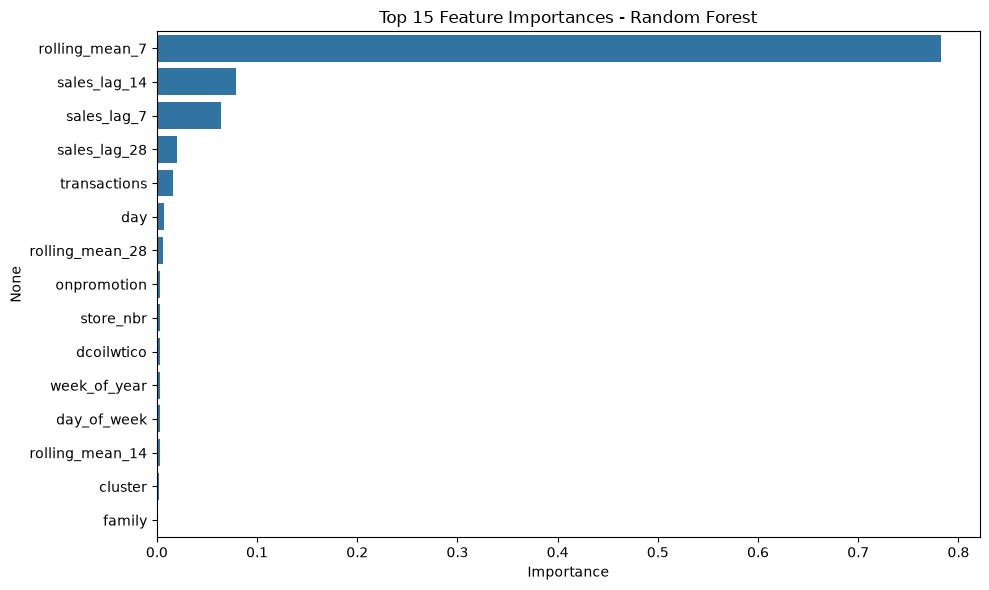

In [9]:
feature_importance = pd.Series(rf_final.feature_importances_, index=X.columns)
top_features = feature_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

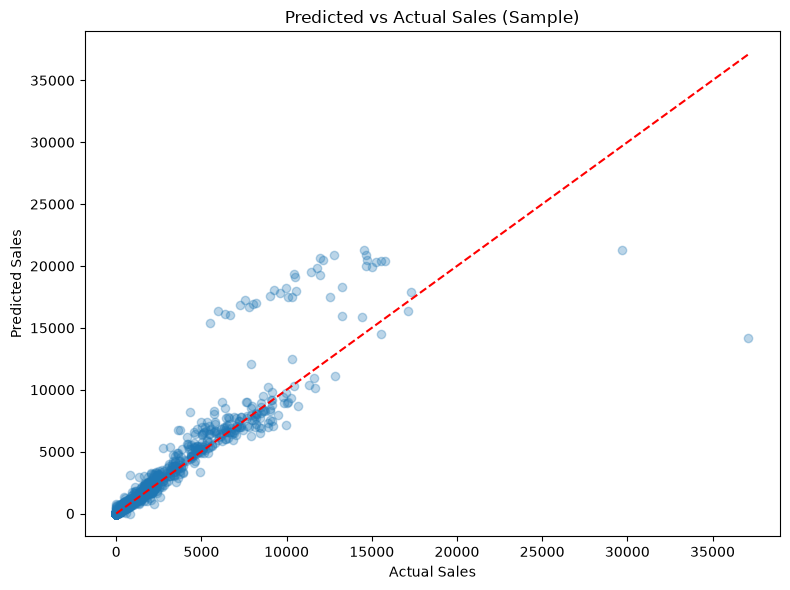

In [10]:
sample_compare = pd.DataFrame({'actual': y_val.values, 'predicted': preds_final}).sample(5000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample_compare['actual'], sample_compare['predicted'], alpha=0.3)
plt.plot([0, sample_compare['actual'].max()], [0, sample_compare['actual'].max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Predicted vs Actual Sales (Sample)')
plt.tight_layout()
plt.show()

## Conclusion

- **Best Model:** Random Forest Regressor
- **Validation RMSLE:** 0.5715
- Lag and rolling mean features (sales_lag_7, sales_lag_14, rolling_mean_7) were by far the most important predictors, confirming that recent sales history is the strongest signal for forecasting
- XGBoost and LightGBM underperformed with default parameters, likely requiring more extensive tuning to compete with Random Forest on this dataset
- The model performs well for typical sales volumes but tends to underestimate exceptionally high sales days, which may correspond to promotions or holiday peaks